In [40]:
import os
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from scipy.stats import bootstrap
from pathlib import Path
import glob

In [41]:
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

In [42]:
#! TODO: Parity Plots
rf_ecfp4 = pd.read_csv("../results/hlm_mlm_test_rf_ecfp4/summary/per_molecule_predictions.csv")
# HLM CLint pred_ensemble_mean, MLM CLint pred_ensemble_mean
chemprop_models = pd.read_csv("../results/hlm_mlm_temporal_80_20_test/summary/per_molecule_predictions.csv")
# HLM CLint chemprop_single_hlm_mean, HLM CLint chemprop_single_foundation_hlm_mean, HLM CLint chemprop_multi_hlm_mlm_mean, HLM CLint chemprop_multi_foundation_hlm_mlm_mean, MLM CLint chemprop_single_mlm_mean, MLM CLint chemprop_single_foundation_mlm_mean, MLM CLint chemprop_multi_hlm_mlm_mean, MLM CLint chemprop_multi_foundation_hlm_mlm_mean


# Ensemble Performance Ranking

In [54]:
rf_ecfp4_ens_met = pd.read_csv(
    "../results/hlm_mlm_test_rf_ecfp4/summary/ensemble_metrics.csv"
)
rf_ecfp4_ens_met["model_family"] = "rf_ecfp4"
display(rf_ecfp4_ens_met)
chemprop_ens_met = pd.read_csv(
    "../results/hlm_mlm_temporal_80_20_test/summary/ensemble_metrics.csv"
)

ens_met = pd.concat([rf_ecfp4_ens_met, chemprop_ens_met], ignore_index=True)

ens_met = ens_met[
    [
        "target",
        "model_family",
        "mae",
        "mae_low_ci",
        "mae_high_ci",
        "rmse",
        "rmse_low_ci",
        "rmse_high_ci",
        "r2",
        "r2_low_ci",
        "r2_high_ci",
        "kendall_tau",
        "kendall_tau_low_ci",
        "kendall_tau_high_ci",
        "kendall_tau_pvalue",
    ]
]

hlm_ens_met = ens_met[ens_met["target"] == "HLM CLint"]
hlm_ens_met = hlm_ens_met.sort_values("mae", ascending=True).reset_index(drop=True)
display(hlm_ens_met)
print(hlm_ens_met.to_markdown(index=False))

mlm_ens_met = ens_met[ens_met["target"] == "MLM CLint"]
mlm_ens_met = mlm_ens_met.sort_values("mae", ascending=True).reset_index(drop=True)
display(mlm_ens_met)
print(mlm_ens_met.to_markdown(index=False))

,target,mae,mae_low_ci,mae_high_ci,rmse,rmse_low_ci,rmse_high_ci,r2,r2_low_ci,r2_high_ci,kendall_tau,kendall_tau_low_ci,kendall_tau_high_ci,kendall_tau_pvalue,model_family
0,HLM CLint,0.375099,0.352463,0.401930,0.475491,0.447514,0.506992,0.005176,-0.139808,0.134180,0.365717,0.307388,0.413674,1.939007e-36,rf_ecfp4
1,MLM CLint,0.443688,0.413979,0.472668,0.561730,0.529326,0.599239,-0.336547,-0.584658,-0.091486,0.248910,0.194929,0.295914,8.795872e-18,rf_ecfp4


,target,model_family,mae,mae_low_ci,mae_high_ci,rmse,rmse_low_ci,rmse_high_ci,r2,r2_low_ci,r2_high_ci,kendall_tau,kendall_tau_low_ci,kendall_tau_high_ci,kendall_tau_pvalue
0,HLM CLint,chemprop_single_foundation_hlm,0.318839,0.296866,0.340343,0.413104,0.388231,0.443606,0.249103,0.151539,0.337162,0.364920,0.307175,0.412117,2.648901e-36
1,HLM CLint,chemprop_multi_foundation_hlm_mlm,0.329681,0.307311,0.351941,0.423461,0.398139,0.452337,0.210979,0.105254,0.296296,0.344082,0.285430,0.396366,1.828384e-32
2,HLM CLint,chemprop_multi_hlm_mlm,0.349752,0.326883,0.373225,0.442114,0.415231,0.474583,0.139940,0.029456,0.239467,0.312018,0.254738,0.364831,5.428603e-27
3,HLM CLint,chemprop_single_hlm,0.352668,0.331014,0.378172,0.447013,0.419349,0.480024,0.120771,-0.003674,0.235202,0.343305,0.288157,0.396141,2.516881e-32
4,HLM CLint,rf_ecfp4,0.375099,0.352463,0.401930,0.475491,0.447514,0.506992,0.005176,-0.139808,0.134180,0.365717,0.307388,0.413674,1.939007e-36


| target    | model_family                      |      mae |   mae_low_ci |   mae_high_ci |     rmse |   rmse_low_ci |   rmse_high_ci |         r2 |   r2_low_ci |   r2_high_ci |   kendall_tau |   kendall_tau_low_ci |   kendall_tau_high_ci |   kendall_tau_pvalue |
|:----------|:----------------------------------|---------:|-------------:|--------------:|---------:|--------------:|---------------:|-----------:|------------:|-------------:|--------------:|---------------------:|----------------------:|---------------------:|
| HLM CLint | chemprop_single_foundation_hlm    | 0.318839 |     0.296866 |      0.340343 | 0.413104 |      0.388231 |       0.443606 | 0.249103   |  0.151539   |     0.337162 |      0.36492  |             0.307175 |              0.412117 |          2.6489e-36  |
| HLM CLint | chemprop_multi_foundation_hlm_mlm | 0.329681 |     0.307311 |      0.351941 | 0.423461 |      0.398139 |       0.452337 | 0.210979   |  0.105254   |     0.296296 |      0.344082 |             0.

,target,model_family,mae,mae_low_ci,mae_high_ci,rmse,rmse_low_ci,rmse_high_ci,r2,r2_low_ci,r2_high_ci,kendall_tau,kendall_tau_low_ci,kendall_tau_high_ci,kendall_tau_pvalue
0,MLM CLint,chemprop_multi_foundation_hlm_mlm,0.367734,0.341109,0.397791,0.493917,0.458753,0.532523,-0.033326,-0.209468,0.152027,0.216905,0.151955,0.268196,7.096981e-14
1,MLM CLint,chemprop_single_foundation_mlm,0.368999,0.344797,0.397739,0.493811,0.458151,0.531247,-0.032884,-0.189757,0.156612,0.204730,0.144841,0.262925,1.596278e-12
2,MLM CLint,chemprop_multi_hlm_mlm,0.403008,0.375478,0.430009,0.519423,0.486054,0.555765,-0.142805,-0.323456,0.058556,0.254997,0.205066,0.305536,1.359259e-18
3,MLM CLint,chemprop_single_mlm,0.424572,0.399691,0.452759,0.531972,0.500316,0.564253,-0.198689,-0.406968,-0.002705,0.198649,0.140556,0.248146,7.081693e-12
4,MLM CLint,rf_ecfp4,0.443688,0.413979,0.472668,0.561730,0.529326,0.599239,-0.336547,-0.584658,-0.091486,0.248910,0.194929,0.295914,8.795872e-18


| target    | model_family                      |      mae |   mae_low_ci |   mae_high_ci |     rmse |   rmse_low_ci |   rmse_high_ci |         r2 |   r2_low_ci |   r2_high_ci |   kendall_tau |   kendall_tau_low_ci |   kendall_tau_high_ci |   kendall_tau_pvalue |
|:----------|:----------------------------------|---------:|-------------:|--------------:|---------:|--------------:|---------------:|-----------:|------------:|-------------:|--------------:|---------------------:|----------------------:|---------------------:|
| MLM CLint | chemprop_multi_foundation_hlm_mlm | 0.367734 |     0.341109 |      0.397791 | 0.493917 |      0.458753 |       0.532523 | -0.0333257 |   -0.209468 |    0.152027  |      0.216905 |             0.151955 |              0.268196 |          7.09698e-14 |
| MLM CLint | chemprop_single_foundation_mlm    | 0.368999 |     0.344797 |      0.397739 | 0.493811 |      0.458151 |       0.531247 | -0.0328838 |   -0.189757 |    0.156612  |      0.20473  |             0.

,model_family,mae,mae_low_ci,mae_high_ci,left_error,right_error
0,ChemProp_ST_FM,0.318839,0.296866,0.340343,0.021973,0.021504
1,ChemProp_MT_FM,0.329681,0.307311,0.351941,0.022370,0.022260
2,ChemProp_MT,0.349752,0.326883,0.373225,0.022869,0.023473
3,ChemProp_ST,0.352668,0.331014,0.378172,0.021654,0.025503
4,RF_ECFP4,0.375099,0.352463,0.401930,0.022635,0.026831


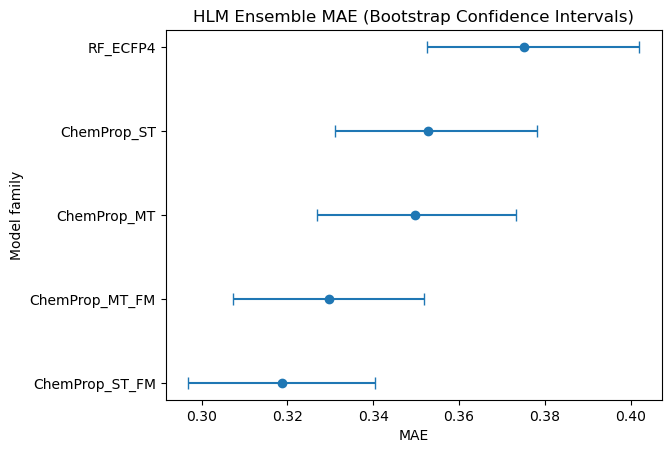

In [46]:
plot_df_hlm = hlm_ens_met[["model_family", "mae", "mae_low_ci", "mae_high_ci"]].copy()

rename_map = {
    "chemprop_multi_foundation_hlm_mlm": "ChemProp_MT_FM",
    "chemprop_single_foundation_hlm": "ChemProp_ST_FM",
    "chemprop_multi_hlm_mlm": "ChemProp_MT",
    "chemprop_single_hlm": "ChemProp_ST",
    "rf_ecfp4": "RF_ECFP4",
}

plot_df_hlm["model_family"] = plot_df_hlm["model_family"].replace(rename_map)

left_error_hlm = plot_df_hlm["mae"] - plot_df_hlm["mae_low_ci"]
right_error_hlm = plot_df_hlm["mae_high_ci"] - plot_df_hlm["mae"]
plot_df_hlm["left_error"] = left_error_hlm
plot_df_hlm["right_error"] = right_error_hlm

errors_hlm = [left_error_hlm, right_error_hlm]

display(plot_df_hlm)

plt.plot(plot_df_hlm["mae"], plot_df_hlm["model_family"], "o")
plt.errorbar(
    x=plot_df_hlm["mae"],
    y=plot_df_hlm["model_family"],
    xerr=errors_hlm,
    fmt="none",
    capsize=4,
)

plt.xlabel("MAE")
plt.ylabel("Model family")
plt.title("HLM Ensemble MAE (Bootstrap Confidence Intervals)")

plt.show()

,model_family,mae,mae_low_ci,mae_high_ci,left_error,right_error
0,ChemProp_MT_FM,0.367734,0.341109,0.397791,0.026625,0.030057
1,ChemProp_ST_FM,0.368999,0.344797,0.397739,0.024202,0.028740
2,ChemProp_MT,0.403008,0.375478,0.430009,0.027530,0.027000
3,ChemProp_ST,0.424572,0.399691,0.452759,0.024882,0.028187
4,RF_ECFP4,0.443688,0.413979,0.472668,0.029709,0.028979


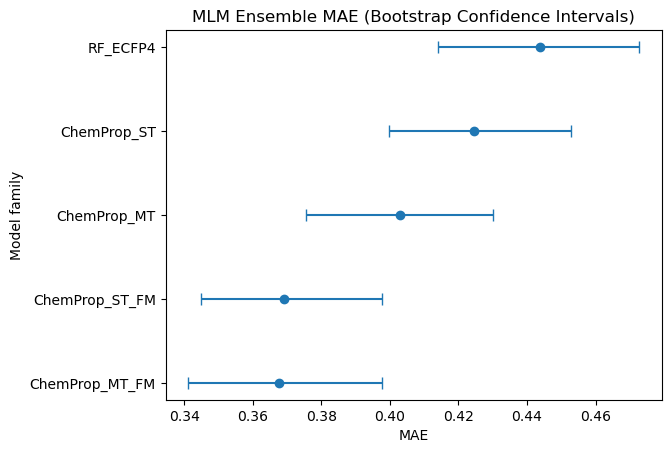

In [47]:
plot_df_mlm = mlm_ens_met[["model_family", "mae", "mae_low_ci", "mae_high_ci"]].copy()

rename_map = {
    "chemprop_multi_foundation_hlm_mlm": "ChemProp_MT_FM",
    "chemprop_single_foundation_mlm": "ChemProp_ST_FM",
    "chemprop_multi_hlm_mlm": "ChemProp_MT",
    "chemprop_single_mlm": "ChemProp_ST",
    "rf_ecfp4": "RF_ECFP4",
}

plot_df_mlm["model_family"] = plot_df_mlm["model_family"].replace(rename_map)

left_error_mlm = plot_df_mlm["mae"] - plot_df_mlm["mae_low_ci"]
right_error_mlm = plot_df_mlm["mae_high_ci"] - plot_df_mlm["mae"]
plot_df_mlm["left_error"] = left_error_mlm
plot_df_mlm["right_error"] = right_error_mlm

errors_mlm = [left_error_mlm, right_error_mlm]

display(plot_df_mlm)

plt.plot(plot_df_mlm["mae"], plot_df_mlm["model_family"], "o")
plt.errorbar(
    x=plot_df_mlm["mae"],
    y=plot_df_mlm["model_family"],
    xerr=errors_mlm,
    fmt="none",
    capsize=4,
)

plt.xlabel("MAE")
plt.ylabel("Model family")
plt.title("MLM Ensemble MAE (Bootstrap Confidence Intervals)")

plt.show()

,model_family,mae,mae_low_ci,mae_high_ci,left_error,right_error
0,ChemProp_ST_FM,0.318839,0.296866,0.340343,0.021973,0.021504
1,ChemProp_MT_FM,0.329681,0.307311,0.351941,0.022370,0.022260
2,ChemProp_MT,0.349752,0.326883,0.373225,0.022869,0.023473
3,ChemProp_ST,0.352668,0.331014,0.378172,0.021654,0.025503
4,RF_ECFP4,0.375099,0.352463,0.401930,0.022635,0.026831


,model_family,mae,mae_low_ci,mae_high_ci,left_error,right_error
0,ChemProp_MT_FM,0.367734,0.341109,0.397791,0.026625,0.030057
1,ChemProp_ST_FM,0.368999,0.344797,0.397739,0.024202,0.028740
2,ChemProp_MT,0.403008,0.375478,0.430009,0.027530,0.027000
3,ChemProp_ST,0.424572,0.399691,0.452759,0.024882,0.028187
4,RF_ECFP4,0.443688,0.413979,0.472668,0.029709,0.028979


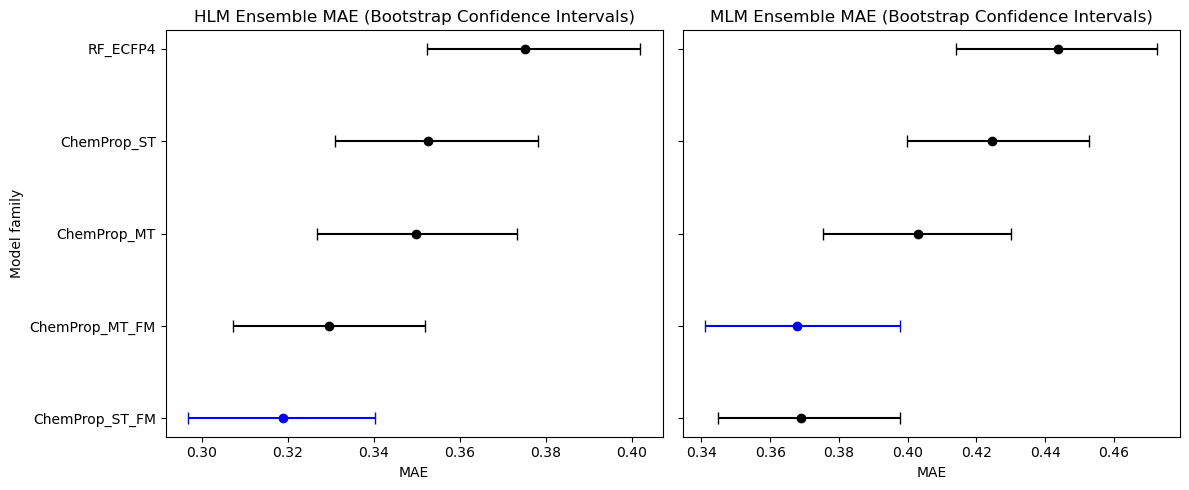

In [53]:
plot_df_hlm = hlm_ens_met[["model_family", "mae", "mae_low_ci", "mae_high_ci"]].copy()

rename_map_hlm = {
    "chemprop_multi_foundation_hlm_mlm": "ChemProp_MT_FM",
    "chemprop_single_foundation_hlm": "ChemProp_ST_FM",
    "chemprop_multi_hlm_mlm": "ChemProp_MT",
    "chemprop_single_hlm": "ChemProp_ST",
    "rf_ecfp4": "RF_ECFP4",
}

plot_df_hlm["model_family"] = plot_df_hlm["model_family"].replace(rename_map_hlm)

left_error_hlm = plot_df_hlm["mae"] - plot_df_hlm["mae_low_ci"]
right_error_hlm = plot_df_hlm["mae_high_ci"] - plot_df_hlm["mae"]
plot_df_hlm["left_error"] = left_error_hlm
plot_df_hlm["right_error"] = right_error_hlm

errors_hlm = [left_error_hlm, right_error_hlm]

display(plot_df_hlm)


plot_df_mlm = mlm_ens_met[["model_family", "mae", "mae_low_ci", "mae_high_ci"]].copy()

rename_map_mlm = {
    "chemprop_multi_foundation_hlm_mlm": "ChemProp_MT_FM",
    "chemprop_single_foundation_mlm": "ChemProp_ST_FM",
    "chemprop_multi_hlm_mlm": "ChemProp_MT",
    "chemprop_single_mlm": "ChemProp_ST",
    "rf_ecfp4": "RF_ECFP4",
}

plot_df_mlm["model_family"] = plot_df_mlm["model_family"].replace(rename_map_mlm)

left_error_mlm = plot_df_mlm["mae"] - plot_df_mlm["mae_low_ci"]
right_error_mlm = plot_df_mlm["mae_high_ci"] - plot_df_mlm["mae"]
plot_df_mlm["left_error"] = left_error_mlm
plot_df_mlm["right_error"] = right_error_mlm

errors_mlm = [left_error_mlm, right_error_mlm]

display(plot_df_mlm)


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Row index of the best model in each dataframe
best_idx_hlm = plot_df_hlm["mae"].idxmin()
best_idx_mlm = plot_df_mlm["mae"].idxmin()

# HLM plot
for i, row in plot_df_hlm.iterrows():
    point_color = "blue" if i == best_idx_hlm else "black"

    axes[0].plot(row["mae"], row["model_family"], "o", color=point_color)
    axes[0].errorbar(
        x=row["mae"],
        y=row["model_family"],
        xerr=[[row["left_error"]], [row["right_error"]]],
        fmt="none",
        ecolor=point_color,
        capsize=4,
    )

axes[0].set_xlabel("MAE")
axes[0].set_ylabel("Model family")
axes[0].set_title("HLM Ensemble MAE (Bootstrap Confidence Intervals)")

# MLM plot
for i, row in plot_df_mlm.iterrows():
    point_color = "blue" if i == best_idx_mlm else "black"

    axes[1].plot(row["mae"], row["model_family"], "o", color=point_color)
    axes[1].errorbar(
        x=row["mae"],
        y=row["model_family"],
        xerr=[[row["left_error"]], [row["right_error"]]],
        fmt="none",
        ecolor=point_color,
        capsize=4,
    )

axes[1].set_xlabel("MAE")
axes[1].set_title("MLM Ensemble MAE (Bootstrap Confidence Intervals)")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "HLM_MLM_Test_MAE.png"), dpi=300, bbox_inches="tight")
plt.show()